In [2]:
import numpy as np
from math import *
import time
def matrixK(n):
    return np.diag([2]*n)+np.diag([-1]*(n-1),1)+np.diag([-1]*(n-1),-1)
def matrixC(n):
    Kn= matrixK(n)
    Kn[0,-1]=-1
    Kn[-1,0]=-1
    return Kn
def matrixT(n):
    Kn= matrixK(n)
    Kn[0,0]=1
    return Kn
def matrixB(n):
    Kn=matrixK(n)
    Kn[0,0]=Kn[-1,-1]=1
    return Kn

In [3]:
import matplotlib.pyplot as plt

In [4]:
N=[9999,10000,10001]
t1=[]
t2=[]
for n in N:
    Kn=matrixK(n)
    f=np.array([n+1]+[0]*(n-1))
    start=time.time()
    u1=np.linalg.solve(Kn,f)
    end1=time.time()
    u2=np.linalg.inv(Kn)@f
    end2=time.time()
    t1.append(end1-start)
    t2.append(end2-end1)

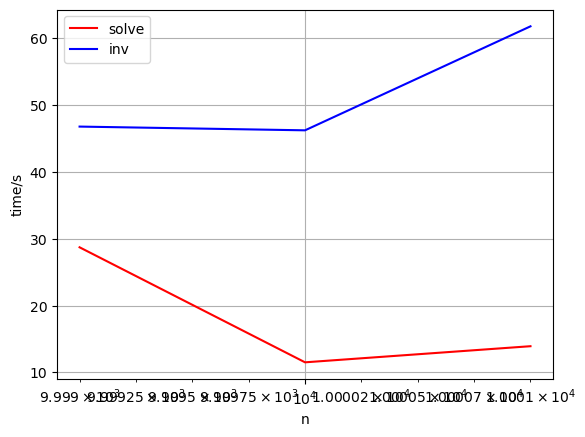

In [5]:
plt.xlabel('n')
plt.ylabel('time/s')
plt.plot(N,t1,label='solve',color='red')
plt.plot(N,t2,label='inv',color='blue')
plt.xscale('log')
plt.grid()
plt.legend()
plt.show()

In [6]:
import numpy as np
np.__config__.show()

{
  "Compilers": {
    "c": {
      "name": "gcc",
      "linker": "ld.bfd",
      "version": "14.3.0",
      "commands": "/home/conda/feedstock_root/build_artifacts/bld/rattler-build_numpy_1770098484/build_env/bin/x86_64-conda-linux-gnu-cc",
      "args": "-march=nocona, -mtune=haswell, -ftree-vectorize, -fPIC, -fstack-protector-strong, -fno-plt, -O2, -ffunction-sections, -pipe, -isystem, /home/lyy/miniconda3/envs/py-openblas/include, -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/bld/rattler-build_numpy_1770098484/work=/usr/local/src/conda/numpy-2.4.2, -fdebug-prefix-map=/home/lyy/miniconda3/envs/py-openblas=/usr/local/src/conda-prefix, -DNDEBUG, -D_FORTIFY_SOURCE=2, -O2, -isystem, /home/lyy/miniconda3/envs/py-openblas/include",
      "linker args": "-Wl,-O2, -Wl,--sort-common, -Wl,--as-needed, -Wl,-z,relro, -Wl,-z,now, -Wl,--disable-new-dtags, -Wl,--gc-sections, -Wl,--allow-shlib-undefined, -Wl,-rpath,/home/lyy/miniconda3/envs/py-openblas/lib, -Wl,-rpath-link,/home/ly

/home/lyy/miniconda3/envs/py-openblas/lib/python3.12/site-packages/numpy/__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)


In [7]:
import io
import contextlib
import numpy as np

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    np.__config__.show()
text = buf.getvalue().lower()

if "openblas" in text and "mkl" not in text:
    print("BLAS backend: OpenBLAS")
elif "mkl" in text:
    print("BLAS backend: MKL (not OpenBLAS)")
elif "openblas" in text and "mkl" in text:
    print("BLAS mentions both OpenBLAS and MKL; check full config")
else:
    print("BLAS backend: unknown, check np.__config__.show() full output")

BLAS backend: OpenBLAS
